<h1 style="text-align: center;"> Projet : Création d'un modèle de TALN de detection d'erreurs de syntaxes de code C</h1>

<h4 style="text-align: center;"> Auteur : BARGO Alfred</h4>

# Introduction

Le langage de programmation C est un langage très repandu et incontournable dans le monde de la programmation. Il a servi à la programmation de plusieurs logiciels et système comme le noyaux du système d'exploitation linux qui a été programmé en C. En même temps qu'il est très utilisé, il est très exigeant en terme de respect de la structure syntaxique. Une absence d'un point-virgule par exemple, erreur très fréquente, à la fin d'une ligne de code stop totalement l'exécution du code. 

Il est donc nécessaire de développer des outils pour aider les developpeurs à non seulement détecter facilement les erreurs dans leurs codes mais aussi à identifier la position probable de cette erreur pour un deboggage rapide. C'est dans ce sens que dans cet projet, nous developpons un modèle d'apprentissage automatique des langues naturelles appellé **TALN** qui, même si le code n'est pas un langue naturel, va permettre d'analyser un bout de code C, detecter s'il y a une ou plusieurs erreurs syntaxiques et les localisers.

Nous allons alors tous d'abord collecté des données brutes de codes C et de formé une base de données. Ensuite, nous allons injecter pour chaque fichier de code correct, des erreurs de syntaxes et définir un vocabulaire de tokens. Après cela, nous allons crée le jeu de données en question, bien structuré. À l'étape suivante, nous allons définir notre modèle d'apprentissage et l'entraîné. Nous allons par la suite, évalué le modèle à travers plusieurs métriques et le sauvegardé. Nous réalisons aussi à l'occasion, le fine tuning d'un modèle pré-entrainé pour des objectifs de comparaisons de performances. Enfin nous allons crée une interface graphique de prédiction.



**Import de bibliothèques**

In [1]:
import os
import random
import json
import re
import math
from tqdm import tqdm

import urllib.request
import zipfile
import shutil

from pycparser.plyparser import Coord
import subprocess
import tempfile
from pycparser import c_parser, parse_file, c_ast, c_lexer
from pycparser.c_lexer import CLexer
from pycparser import preprocess_file

import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from collections import Counter
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_score, recall_score, f1_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import recall_score
from torch.utils.data import WeightedRandomSampler
import warnings

import traceback

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

**Configuration des chemins**

In [14]:
LABELS_DIR = "Données/Données_étiquettes"
VOCAB_PATH = "Données/vocab.pkl"
MODEL_SAVE_DIR = "modèle/models"
RESULTS_DIR = "résultats/results"

source_dir = "Données/Codes_valides"
errored_dir = "Données/Codes_invalides"
dataset_dir = "Données/Données_étiquettes"
label_dir = "Données/Données_étiquettes"

os.makedirs(dataset_dir, exist_ok=True)
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

<h1 style="text-align: center;">PARTIE I</h1>

<h4 style="text-align: center;">Mise en place du jeu de données</h4>

# I. Corpus de code (dataset)

Avant tout, il est nécessaire de constitué un corpus de code C assez conséquent pour l'entraînement.

* **Sources**

Nous avons télécharger du code C diversifié sur GitHub à plusieurs adresses. 

Adresses de code GitHub télécharger :

* [https://github.com/FormAI-Dataset/FormAI-dataset]
* [https://github.com/gouravthakur39/beginners-C-program-examples]
* [https://github.com/h0mbre/Learning-C]
* [https://github.com/migiFi]
* [https://github.com/amantiwari8861/C_Batch_11_to_12]
* [https://github.com/YajanaRao/C-Programs/tree/master/tutorial]
* [https://github.com/Ratheshprabakar/C-Complete-practice]


* **Description du jeu de données**

Le jeu de données est un ensemble de fichiers d'extension **.c** contenant chacun, du code en langage C. Ces codes partent de quelques dizaines de lignes à des centaines de lignes (574).

Les fichiers de codes sont au nombres de 14 934. 

<h1 style="text-align: center;">PARTIE II</h1>

<h4 style="text-align: center;">Prétraitement des données et construction puis entraînement d'un modèle local</h4>

# I. Prétraitement des données

## II.1 Tokénisation

* **Téléchargement du tokenizer pycparser**

In [ ]:
# Télécharger le fichier
#url = "https://github.com/eliben/pycparser/archive/master.zip"
#urllib.request.urlretrieve(url, "master.zip")

# Extraire le zip
#with zipfile.ZipFile("master.zip", 'r') as zip_ref:
#    zip_ref.extractall(".")

# Copier le dossier
#shutil.copytree("pycparser-main/utils/fake_libc_include", "./fake_libc_include")

**Interprétation :**

Il s'agit ici de télécharger les fichiers depuis internet qui permettent de gérer les macro *#include*, *#define* et bien d'autres qui sont toujours au début des fichiers de code. Cela permettra de les traites convenablement par la suite et de ne pas les considérer comme des tokens ordinaires. En fait, nous allons utilisé la tokenisation avec le lexer pycparser. Pour exploiter toute la puissance de cette tokenisation alors, il faut supprimer les directives preprocesseurs au debut des codes. C'est donc normal que nous telechargeons les fichiers de gestions de mocros.

* **Tokenisation du code avec le lexer de pycparser**

Cette tokenisation utilise le compilateur gcc pour résoudre les macros et en plus de cela, inclus les types des tokens pour enrichir le vocabulaire.

In [ ]:
gcc_folder=r'C:\msys64\ucrt64\bin'
gcc_path=os.path.join(gcc_folder, 'gcc.exe')
os.environ['PATH'] = gcc_folder + os.pathsep + os.environ.get('PATH', '')

def tokenize_code_with_pycparser(code, cpp_path=gcc_path, fake_libc_path='fake_libc_include'):
    """
    Tokenise du code C en utilisant le lexer de pycparser après préprocessing.
    Retourne (tokens, line_numbers, token_types).
    """

    # Suppression des codes liés aux macros
    code_no_includes = re.sub(r'#include\s+<.*?>', '', code)
    code = re.sub(r'#include\s+".*?"', '', code_no_includes)
    
    with tempfile.NamedTemporaryFile(mode='w', suffix='.c', delete=False) as tmp:
        tmp.write(code)
        tmp_name = tmp.name

    try:
        cpp_args = ['-E', f'-I{fake_libc_path}']
        preprocessed = preprocess_file(tmp_name, cpp_path=cpp_path, cpp_args=cpp_args)

        def error_func(msg, line, column): pass
        def on_lbrace_func(): pass
        def on_rbrace_func(): pass
        def type_lookup_func(ident): return None

        lexer = CLexer(error_func, on_lbrace_func, on_rbrace_func, type_lookup_func)
        lexer.build()
        lexer.input(preprocessed)

        tokens = []
        line_numbers = []
        token_types = []
        while True:
            tok = lexer.token()
            if not tok:
                break
            tokens.append(tok.value)
            line_numbers.append(tok.lineno)
            token_types.append(tok.type)  # par exemple, 'IDENTIFIER', 'CONSTANT', etc.
        return tokens, line_numbers, token_types
    finally:
        os.unlink(tmp_name)

* **Tokenisation sans preprocesseur gcc**

  Cette tokenisation n'utilise pas le compilateur gcc, donc ne résoud pas les macros. Elle renvoie par contre, les token, les numéros de lignes et les types.

In [ ]:
def tokenize_without_preprocessor(code):
    """Tokenise sans préprocesseur (lexer seul)."""
    def error_func(msg, line, column): pass
    def on_lbrace_func(): pass
    def on_rbrace_func(): pass
    def type_lookup_func(ident): return None
    lexer = CLexer(error_func, on_lbrace_func, on_rbrace_func, type_lookup_func)
    lexer.build()
    lexer.input(code)
    tokens = []
    line_numbers = []
    token_types = []
    while True:
        tok = lexer.token()
        if not tok:
            break
        tokens.append(tok.value)
        line_numbers.append(tok.lineno)
        token_types.append(tok.type)
    return tokens, line_numbers, token_types

* **Exemple avec un petit code**

In [ ]:
code = "#include <stdio.h>\nint main() { a=5; printf('%d',a); printf(\"Hello\"); return 0; }"
tokens, lines, token_types = tokenize_code_with_pycparser(code)
print(tokens)
print(lines)
print(token_types)

**Interprétation :**

Avec cet exemple, on peut bien voir que non seulement la directive preprocesseur *#include* n'est pas retourné comme token (gérer directement), mais aussi que les tokens sont retournés avec leurs types défini par le tokeniseur. Cela est important pour régrouper les tokens par la suite par types dans le vocabulaire de tokens.

## II.2 Injection d'erreurs syntaxiques

* **Catalogue d'erreurs à injecté**

Cet code donne le catalogue d'erreurs à injectées, avec les action et leurs descriptions.

In [ ]:

# --- Fonctions de tokenisation et AST (à définir ailleurs) ---
# from tokenizer import tokenize_code_with_pycparser
# from ast_builder import build_ast

# --- Classes d'erreurs (reprise de votre code) ---
class ErrorType:
    def __init__(self, name, description, category, condition_func, apply_func, prob=0.7):
        self.name = name
        self.description = description
        self.category = category
        self.condition_func = condition_func
        self.apply_func = apply_func
        self.prob = prob  # probabilité d'application si le token est éligible

    def applies(self, token, token_type, context=None):
        return self.condition_func(token, token_type, context)

    def apply(self, line, pos, token, context=None):
        return self.apply_func(line, pos, token, context)

# Fonctions de condition simples
def cond_token_eq(value):
    return lambda token, token_type, context: token == value

def cond_token_regex(pattern):
    return lambda token, token_type, context: re.fullmatch(pattern, token) is not None

def cond_type_eq(ttype):
    return lambda token, token_type, context: token_type == ttype

def cond_always_true(token, token_type, context):
    return True

def cond_assign_instead_of_equality(token, token_type, context):
    # context contient l'AST
    # Vérifier si le token '=' est dans une condition (if, while, for)
    # Pour l'instant, on ne l'active pas (retourne False)
    return False

# Fonctions d'application de base
def apply_delete(line, pos, token, context):
    new_line = line[:pos] + '<DEL>' + line[pos+len(token):]
    return new_line, f'MISSING_{token}'

def apply_replace(replace_with):
    def _apply(line, pos, token, context):
        new_line = line[:pos] + replace_with + line[pos+len(token):]
        return new_line, f'REPLACE_{token}'
    return _apply

def apply_insert(insert):
    def _apply(line, pos, token, context):
        new_line = line[:pos+len(token)] + insert + line[pos+len(token):]
        return new_line, f'EXTRA_{insert}'
    return _apply

def apply_typo(line, pos, token, context):
    if len(token) > 2:
        idx = random.randint(0, len(token)-1)
        new_char = chr(random.randint(ord('a'), ord('z')))
        new_token = token[:idx] + new_char + token[idx+1:]
        new_line = line[:pos] + new_token + line[pos+len(token):]
        return new_line, f'TYPO_{token}'
    return line, 'CORRECT'

'''def apply_unexpected(line, pos, token, context):
    # Insère un caractère parasite après le token
    insert = random.choice(['@', '#', '$', '%'])
    new_line = line[:pos+len(token)] + insert + line[pos+len(token):]
    return new_line, 'UNEXPECTED_TOKEN'''

ERROR_CATALOG = [
    ErrorType('MISSING_SEMICOLON', 'Point-virgule manquant', 'punctuation',
              cond_token_eq(';'),
              lambda line, pos, token, ctx: (line[:pos] + '<DEL>' + line[pos+1:], 'MISSING_SEMICOLON'),
              prob=0.70),
    ErrorType('EXTRA_SEMICOLON', 'Point-virgule en trop', 'punctuation',
              cond_token_eq(';'),
              lambda line, pos, token, ctx: (line[:pos+1] + ';' + line[pos+1:], 'EXTRA_SEMICOLON'),
              prob=0.60),
    ErrorType('MISSING_PAREN', 'Parenthèse manquante', 'punctuation',
              cond_token_regex(r'\(|\)'),
              lambda line, pos, token, ctx: (line[:pos] + '<DEL>' + line[pos+len(token):], 'MISSING_PAREN'),
              prob=0.85),
    ErrorType('MISSING_BRACE', 'Accolade manquante', 'punctuation',
              cond_token_regex(r'\{|\}'),
              lambda line, pos, token, ctx: (line[:pos] + '<DEL>' + line[pos+len(token):], 'MISSING_BRACE'),
              prob=0.85),
    ErrorType('WRONG_OPERATOR_EQ', '= au lieu de ==', 'operator',
              cond_token_eq('=='),  # ← corrigé
              lambda line, pos, token, ctx: (line[:pos] + '=' + line[pos+2:], 'WRONG_OPERATOR_EQ'),
              prob=0.75),
    ErrorType('WRONG_OPERATOR_ASSIGN', '== au lieu de =', 'operator',
              cond_token_eq('='),
              lambda line, pos, token, ctx: (line[:pos] + '==' + line[pos+1:], 'WRONG_OPERATOR_ASSIGN'),
              prob=0.75),
    ErrorType('TYPO_WHILE', 'Faute de frappe sur while', 'keyword',
              cond_token_eq('while'),
              apply_typo,
              prob=0.85),
    ErrorType('TYPO_INT', 'Faute de frappe sur int', 'keyword',
              cond_token_eq('int'),
              apply_typo,
              prob=0.85),
    ErrorType('KEYWORD_TYPO', 'Faute de frappe sur mot-clé', 'keyword',
              cond_token_regex(r'\b(int|return|while|if|else|for|include|void|char|double|struct|static)\b'),
              apply_typo,
              prob=0.92),
    ErrorType('DIRECTIVE_MALFORMED', 'Directive mal formée (#include)', 'preprocessor',
              cond_token_eq('#include'),
              lambda line, pos, token, ctx: (line[:pos] + 'include' + line[pos+7:], 'DIRECTIVE_MALFORMED'),
              prob=0.69),
]

# Ajout de l'erreur contextuelle
ERROR_CATALOG.append(
    ErrorType('ASSIGN_INSTEAD_OF_EQUALITY', '= au lieu de == dans une condition', 'contextual',
              cond_assign_instead_of_equality,
              lambda line, pos, token, ctx: (line[:pos] + '==' + line[pos+1:], 'ASSIGN_INSTEAD_OF_EQUALITY'),
              prob=0.65)
)

# Dictionnaire pour accès rapide (corrigé)
ERROR_BY_NAME = {err.name: err for err in ERROR_CATALOG}

In [ ]:
print(ERROR_BY_NAME)

**Interprétation :**

Nous enumérons ici les différents types d'erreurs qui sont considérées comme des classes que le modèle dont nous souhaiterons contruire par la suite aura à classer.

**Configuration**

In [ ]:
ERROR_PROBABILITY_GLOBAL = 0.90  # probabilité qu'un token soit considéré pour une erreur (premier filtre)
USE_ADAPTIVE_WEIGHTS = True       # activer l'équilibrage dynamique
RARITY_FACTOR = 1.5               # facteur pour amplifier les poids des classes rares (1 = inverse, plus grand = plus de rareté)

* **Construction de l'arbre syntaxique (AST)**


In [ ]:
def build_ast(code, cpp_path=gcc_path, fake_libc_path='fake_libc_include'):
    """Construit l'AST à partir du code."""
    with tempfile.NamedTemporaryFile(mode='w', suffix='.c', delete=False) as tmp:
        tmp.write(code)
        tmp_name = tmp.name
    try:
        cpp_args = ['-E', f'-I{fake_libc_path}']
        ast = parse_file(tmp_name, use_cpp=True, cpp_path=cpp_path, cpp_args=cpp_args)
        return ast
    finally:
        os.unlink(tmp_name)

**Interprétation :**

 Ce code permet de construire un arbre de syntaxe. Avec cet arbre, le code n'est plus considéré comme une suite de tokens, mais comme une suite de tokens avec une certaine structure de logique. Le modèle apprendra par exemple à travers les embeddings des tokens que la fermeture d'une accolade signifie qu'à quelque part dans les lignes précédentes, une accolade a été ouverte.

 Cela donne encore plus de pouvoir d'interprétabilité au modèle.

* **Génération des données avec injection des erreurs**

In [ ]:
def inject_errors_in_file(filepath, global_stats):
    with open(filepath, 'r', encoding='utf-8') as f:
        code = f.read()

    tokens, line_numbers, token_types = tokenize_code_with_pycparser(code)
    ast = build_ast(code)

    lines = code.splitlines(keepends=True)
    all_tokens, all_labels, all_positions, all_types = [], [], [], []

    token_idx = 0
    for line_num, line in enumerate(lines, 1):
        line_tokens, line_types = [], []
        while token_idx < len(tokens) and line_numbers[token_idx] == line_num:
            line_tokens.append(tokens[token_idx])
            line_types.append(token_types[token_idx])
            token_idx += 1

        if not line_tokens:
            continue

        modified_tokens, modified_labels, modified_types = [], [], []

        for token, ttype in zip(line_tokens, line_types):
            # Premier filtre : probabilité globale de considérer ce token
            if random.random() < ERROR_PROBABILITY_GLOBAL:
                # Récupérer toutes les erreurs applicables à ce token
                applicable = [err for err in ERROR_CATALOG if err.applies(token, ttype, {'ast': ast})]
                if applicable:
                    if USE_ADAPTIVE_WEIGHTS:
                        # Calculer les poids en fonction de la rareté observée
                        # global_stats contient le nombre d'occurrences de chaque erreur déjà vue
                        weights = []
                        for err in applicable:
                            count = global_stats.get(err.name, 0) + 1  # +1 pour éviter division par zéro
                            # Plus une erreur est rare, plus son poids est élevé
                            # On peut ajuster avec un facteur de rareté
                            weight = 1.0 / (count ** RARITY_FACTOR)
                            weights.append(weight)
                        # Normaliser pour que la somme = 1
                        total = sum(weights)
                        weights = [w / total for w in weights]
                        err = random.choices(applicable, weights=weights, k=1)[0]
                    else:
                        # Sinon, choisir uniformément parmi les erreurs applicables
                        err = random.choice(applicable)

                    
                    # ============== Nouveau =================
                    if err.name in ['MISSING_SEMICOLON', 'MISSING_PAREN', 'MISSING_BRACE']:
                        if modified_tokens:
                            # Le dernier token de la ligne courante porte maintenant l'erreur
                            modified_labels[-1] = err.name
                            # Ne pas ajouter le token courant (le symbole supprimé)
                            continue
                        else:
                            # Cas improbable : premier token de la ligne, on le garde sans erreur
                            modified_tokens.append(token)
                            modified_labels.append('CORRECT')
                            modified_types.append(ttype)
                            continue
                    
                    elif err.name == 'EXTRA_SEMICOLON':
                        modified_tokens.append(token)
                        modified_labels.append('CORRECT')
                        modified_types.append(ttype)
                        modified_tokens.append(';')
                        modified_labels.append(err.name)
                        modified_types.append('PUNCTUATION')
                    elif err.name == 'WRONG_OPERATOR_EQ':
                        modified_tokens.append('=')
                        modified_labels.append(err.name)
                        modified_types.append('OPERATOR')
                    elif err.name == 'WRONG_OPERATOR_ASSIGN':
                        modified_tokens.append('==')
                        modified_labels.append(err.name)
                        modified_types.append('OPERATOR')
                    elif err.name.startswith('TYPO_') or err.name == 'KEYWORD_TYPO':
                        # Appliquer la typo via la fonction apply_typo (on simule ici)
                        if len(token) > 2:
                            idx = random.randint(0, len(token)-1)
                            new_char = chr(random.randint(ord('a'), ord('z')))
                            new_token = token[:idx] + new_char + token[idx+1:]
                            modified_tokens.append(new_token)
                            modified_labels.append(err.name)
                            modified_types.append('IDENTIFIER')
                        else:
                            modified_tokens.append(token)
                            modified_labels.append('CORRECT')
                            modified_types.append(ttype)
                    elif err.name == 'DIRECTIVE_MALFORMED':
                        modified_tokens.append('include')
                        modified_labels.append(err.name)
                        modified_types.append('PREPROCESSOR')
                    else:
                        # Fallback : ne pas modifier
                        modified_tokens.append(token)
                        modified_labels.append('CORRECT')
                        modified_types.append(ttype)
                    continue  # token traité, passer au suivant

            # Si aucune erreur n'a été appliquée, on garde le token original
            modified_tokens.append(token)
            modified_labels.append('CORRECT')
            modified_types.append(ttype)

        # Reconstruire la ligne (simple jointure avec espace)
        lines[line_num-1] = ' '.join(modified_tokens) + '\n'
        all_tokens.extend(modified_tokens)
        all_labels.extend(modified_labels)
        all_positions.extend([line_num] * len(modified_tokens))
        all_types.extend(modified_types)

    # Sauvegarde des fichiers
    errored_code = ''.join(lines)
    base = os.path.splitext(os.path.basename(filepath))[0]

    errored_path = os.path.join(errored_dir, f"{base}_errored.txt")
    with open(errored_path, 'w', encoding='utf-8') as f:
        f.write(errored_code)

    label_data = {
        "metadata": {
            "source_file": os.path.basename(filepath),
            "total_tokens": len(all_tokens),
            "error_count": sum(1 for l in all_labels if l != 'CORRECT'),
            "error_types": list(set(l for l in all_labels if l != 'CORRECT'))
        },
        "sequence": {
            "tokens": all_tokens,
            "labels": all_labels,
            "line_numbers": all_positions,
            "token_types": all_types
        }
    }

    label_path = os.path.join(label_dir, f"{base}_labels.json")
    with open(label_path, 'w', encoding='utf-8') as f:
        json.dump(label_data, f, indent=2)

    return label_data

**Résumé :**

Le jeu de données que nous avons mis en œuvre est constitué de 14 934 fichiers .c de codes correcte. Dans chacune de ces fichiers de code, nous injectons des erreurs et reconstruisons un fichier équivalent qui contient le code erroné. Les lables pour chaque erreur injecté, les numéros de lignes des tokens et les types de tokens sont eux, régroupés dans un autre fichier JSON.

Pour l'injection des erreurs, le principe est que l'on regarde pour chaque token, la modification qu'il peu subir, et parmi les actions auxquelles il est candidat, on choisit une action aléatoire que l'on applique sur lui. Les probabilités d'injections sont définies localement par classe d'erreur et aussi globalement pour gérer la quantité d'erreurs injectées.

Particulièrement pour l'injection d'erreur necessitant la suppression du token comme l'erreur de **MISSING_SEMICOLON**, au lieu de remplacé le token supprimé par le token \<DEL\> pour ensuite le labelisé, nous labelisons par contre le token qui précède celui supprimé. Comme cela, lorsque le modèle rencontre un dernier token qui porte le label par exemple **MISSING_SEMICOLON** il reconnaît qu'àprès ce token doit suivre un point virgule.

* **Appel**

In [ ]:
if __name__ == '__main__':

    files = [f for f in os.listdir(source_dir) if f.endswith(('.c', '.txt'))]
    global_stats = Counter()
    metrics = {"success": 0, "deleted": 0, "total_errors": 0}

    print(f"🚀 Début du traitement de {len(files)} fichiers...")

    for fname in tqdm(files, desc="Injection", unit="file"):
        fpath = os.path.join(source_dir, fname)
        try:
            res = inject_errors_in_file(fpath, global_stats)
            metrics["success"] += 1
            metrics["total_errors"] += res['metadata']['error_count']
            # Mise à jour des stats pour l'équilibrage du prochain fichier
            global_stats.update([l for l in res['sequence']['labels'] if l != 'CORRECT'])

        except Exception as e:
            #print(f"Erreur sur {fname}: {e}")
            # Optionnel : supprimer le fichier source
            try:
                os.remove(fpath)
                metrics["deleted"] += 1
                 
            except:
                print(f"Impossible de supprimer le fichier {fname} : {e}")
                continue

    # --- AFFICHAGE FINAL ---
    print(f"\n✅ Terminés: {metrics['success']} | 🗑️ Supprimés: {metrics['deleted']}")
    print("-" * 50)
    print(f"{'Type erreur':<25} | {'Nombre':<10} | {'%'}")
    for err, count in global_stats.most_common():
        perc = (count / metrics["total_errors"] * 100) if metrics['total_errors'] > 0 else 0
        print(f"{err:<25} | {count:<10} | {perc:.2f}%")

* **Interprétation**

    Pour avoir une représentation assez significative pour chaque type d'errreur, nous avons réalisé l'injection à chaque instant dans le fichier courant, en tenant compte des statistiques des classes d'erreurs à travers les injections passées. Avec cela, si à l'instant t, une classe est majoritaire et qu'à un token donné on peut injecté une autre catégorie d'erreur dont la classe est minoritaire, alors on procède à l'injection de l'erreur de classe minoritaire. Ainsi, on réduit ne serait-ce que un peu, le fait que certaines classe d'erreurs aient ou presque pas de support à la fin du traitement des fichiers.

## II.3 Construction du vocabulaire de tokens

* **Construction du vocabulaire**

In [ ]:
def build_vocabulary():
    counter = Counter()
    for fname in os.listdir(errored_dir):
        if fname.endswith('.txt'):
            with open(os.path.join(errored_dir, fname), 'r', encoding='utf-8') as f:
                code = f.read()
            tokens, _, _ = tokenize_without_preprocessor(code)  # Pas de préprocesseur
            counter.update(tokens)

    vocab_items = counter.most_common()
    special_tokens = ['<PAD>', '<UNK>', '<DEL>']
    itos = special_tokens + [token for token, _ in vocab_items]
    stoi = {token: i for i, token in enumerate(itos)}

    vocab_data = {
        'stoi': stoi,
        'itos': itos,
        'vocab_size': len(itos),
        'frequencies': dict(vocab_items)
    }
    with open(VOCAB_PATH, 'wb') as f:
        pickle.dump(vocab_data, f)
    print(f"Vocabulaire construit : {len(itos)} tokens")

if __name__ == '__main__':
    build_vocabulary()

**Interprétation :**

Il y a en résumé, 114 783 tokens qui constituent le vocabulaire.

Le fichier de vocabulaire que nous avons crée ici au format pickle regroupe tout les tokens présents dans les fichiers de code, de manière unique pour la reconnaissance. Les tokens jamais vu sont spécialement appelés \<UNK\>, et le token \<PAD\> est utilisé pour remplir le vide dans les fichiers de codes très court par rapport aux autres.
Dans ce fichier, les tokens sont également régrouper par types.

* **Focal Loss pour un apprentissage centré  sur les exemples rares**

In [3]:
class FocalLoss(nn.Module):
    """
    Focal Loss pour classification multi-classes avec déséquilibre extrême.
    Combinée avec les poids de classes pour un double effet rééquilibrant.
    
    gamma=2 : valeur standard recommandée dans le papier original (Lin et al. 2017)
    """
    def __init__(self, gamma=2.0, weight=None, ignore_index=-100, label_smoothing=0.1):
        super().__init__()
        self.gamma          = gamma
        self.weight         = weight        # poids par classe
        self.ignore_index   = ignore_index
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        """
        logits  : (N, C) — logits bruts
        targets : (N,)   — indices des classes cibles
        """
        # Masque pour ignorer le padding
        valid_mask = targets != self.ignore_index
        logits  = logits[valid_mask]
        targets = targets[valid_mask]

        if logits.numel() == 0:
            return torch.tensor(0.0, requires_grad=True, device=logits.device)

        # Cross-entropy avec label smoothing
        ce_loss = F.cross_entropy(
            logits, targets,
            weight=self.weight,
            reduction='none',
            label_smoothing=self.label_smoothing
        )

        # Probabilité de la classe correcte : p_t
        probs = F.softmax(logits, dim=-1)
        p_t   = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        p_t   = p_t.clamp(1e-6, 1.0 - 1e-6)

        # Facteur focal : (1 - p_t)^gamma
        focal_factor = (1.0 - p_t) ** self.gamma
        focal_loss   = focal_factor * ce_loss

        return focal_loss.mean()

**Interprétation :**

Avec des classes d'erreurs déséquilibrées, les performances du modèle apprises pourront être biaisées puisque celui-ci ne rencontre presque pas certaines types d'erreurs. Ainsi, nous utilisons **Focal Loss**, une fonction de perte qui prend en compte le déséquilibre des classeset résoud ce problème grace à l'ajout d'un facteur de modulation  $(1 - p_t)^\gamma$ dans la fonction de perte **CrossEntropy**.

Elle permet dans notre cas de réduire le poids des exemples faciles comme **CORRECT**, **EXTRA_SEMICOLON** et concentre
l'apprentissage sur les exemples difficiles (KEYWORD_TYPO, MISSING_BRACE).

Formulation mathématique :

$$\text{FL}(p_t) = -\alpha_t (1 - p_t)^\gamma \log(p_t)$$

    - γ=0 : Cross-Entropy classique
    - γ=2 : Les exemples bien classifiés (p>0.9) ont un poids ~100x plus faible

* **Classe Dataset avec gestion des types de tokens**

In [4]:
# Dataset avec regroupement des typo
class CErrorDatasetV2(Dataset):
    """
    Dataset V2 avec :
    - Regroupement TYPO_INT + TYPO_WHILE → KEYWORD_TYPO
    - Calcul des poids sqrt(inverse_freq) pour WeightedRandomSampler
    - Pas de x20 interne (corrigé en V1)
    """
    def __init__(self, json_files, vocab_path,
                 window_size=512, stride=256,
                 typo_merge_map=None):
        self.typo_merge_map = typo_merge_map or {}

        with open(vocab_path, 'rb') as f:
            vocab_data = pickle.load(f)
        self.stoi       = vocab_data['stoi']
        self.vocab_size = vocab_data['vocab_size']

        # Construire les mappings APRÈS regroupement
        self.label2id = self._build_label_mapping(json_files)
        self.id2label = {v: k for k, v in self.label2id.items()}
        self.num_classes = len(self.label2id)

        self.type2id  = self._build_type_mapping(json_files)
        self.num_types = len(self.type2id)

        self.segments = []
        self.segment_dominant_labels = []
        correct_id = self.label2id.get('CORRECT', 0)
        unk_id     = self.stoi.get('<UNK>', 0)

        for path in json_files:
            with open(path, 'r', encoding='utf-8') as f:
                data = json.load(f)
            tokens       = data['sequence']['tokens']
            labels       = data['sequence']['labels']
            line_numbers = data['sequence']['line_numbers']
            token_types  = data['sequence']['token_types']

            # Appliquer le regroupement des typos
            labels = [self.typo_merge_map.get(l, l) for l in labels]

            for start in range(0, len(tokens), stride):
                end = start + window_size
                seg_tokens = tokens[start:end]
                seg_labels = labels[start:end]
                seg_lines  = line_numbers[start:end]
                seg_types  = token_types[start:end]
                if not seg_tokens:
                    continue

                token_ids = [self.stoi.get(tok, unk_id) for tok in seg_tokens]
                label_ids = [self.label2id.get(lbl, correct_id) for lbl in seg_labels]
                type_ids  = [self.type2id.get(t, 0) for t in seg_types]

                # Label dominant pour WeightedRandomSampler
                non_correct = [l for l in label_ids if l != correct_id]
                dominant = non_correct[0] if non_correct else correct_id

                self.segments.append({
                    'token_ids':    torch.tensor(token_ids,  dtype=torch.long),
                    'label_ids':    torch.tensor(label_ids,  dtype=torch.long),
                    'line_numbers': torch.tensor(seg_lines,  dtype=torch.long),
                    'type_ids':     torch.tensor(type_ids,   dtype=torch.long),
                })
                self.segment_dominant_labels.append(dominant)

        print(f'  → {len(self.segments)} segments | {self.num_classes} classes')

    def _merge_label(self, lbl):
        return self.typo_merge_map.get(lbl, lbl)

    def _build_label_mapping(self, json_files):
        all_labels = set()
        for path in json_files:
            with open(path, 'r') as f:
                data = json.load(f)
            for lbl in data['sequence']['labels']:
                all_labels.add(self.typo_merge_map.get(lbl, lbl))
        sorted_labels = sorted(all_labels)
        if 'CORRECT' in sorted_labels:
            sorted_labels.remove('CORRECT')
            sorted_labels = ['CORRECT'] + sorted_labels
        return {lbl: i for i, lbl in enumerate(sorted_labels)}

    def _build_type_mapping(self, json_files):
        all_types = set()
        for path in json_files:
            with open(path, 'r') as f:
                data = json.load(f)
            all_types.update(data['sequence']['token_types'])
        return {t: i+1 for i, t in enumerate(sorted(all_types))}

    def get_sampler_weights(self):
        """
        Poids sqrt(inverse_freq) : plus équilibré que l'inverse exact.
        Évite de sur-amplifier TYPO_WHILE (211 exemples → poids de 1980x avec balanced).
        sqrt donne un poids de ~44x, bien plus raisonnable.
        """
        label_counts = Counter(self.segment_dominant_labels)
        total = len(self.segment_dominant_labels)
        weights = [
            math.sqrt(total / label_counts[lbl])
            for lbl in self.segment_dominant_labels
        ]
        return torch.tensor(weights, dtype=torch.float)

    def get_class_weights_for_loss(self):
        """
        Poids sqrt(inverse_freq) pour la Focal Loss.
        Retourne un tenseur de taille (num_classes,).
        """
        # Compter les tokens (pas les segments)
        label_counts = Counter()
        for seg in self.segments:
            for lbl_id in seg['label_ids'].tolist():
                label_counts[lbl_id] += 1
        total = sum(label_counts.values())
        weights = torch.zeros(self.num_classes)
        for cls_id in range(self.num_classes):
            count = label_counts.get(cls_id, 1)
            weights[cls_id] = math.sqrt(total / count)
        # Normaliser pour que la moyenne = 1
        weights = weights / weights.mean()
        return weights

    def __len__(self):
        return len(self.segments)

    def __getitem__(self, idx):
        seg = self.segments[idx]
        return seg['token_ids'], seg['label_ids'], seg['line_numbers'], seg['type_ids']


def collate_fn(batch):
    token_ids_list  = [item[0] for item in batch]
    label_ids_list  = [item[1] for item in batch]
    line_ids_list   = [item[2] for item in batch]
    type_ids_list   = [item[3] for item in batch]

    token_ids_padded = nn.utils.rnn.pad_sequence(token_ids_list, batch_first=True, padding_value=0)
    label_ids_padded = nn.utils.rnn.pad_sequence(label_ids_list, batch_first=True, padding_value=-100)
    line_ids_padded  = nn.utils.rnn.pad_sequence(line_ids_list,  batch_first=True, padding_value=0)
    type_ids_padded  = nn.utils.rnn.pad_sequence(type_ids_list,  batch_first=True, padding_value=0)

    return {
        'token_ids':      token_ids_padded,
        'labels':         label_ids_padded,
        'line_numbers':   line_ids_padded,
        'type_ids':       type_ids_padded,
        'attention_mask': (token_ids_padded != 0).long(),
        'lengths':        torch.tensor([len(s) for s in token_ids_list]),
    }

**Analyse :**

Nous créons la classe **CErrorDatasetV2** utilisant le vocabulaire de tokens, augmentons le nombre d'exemples de classes rares avec un ré-échantillonnage aléatoire sur la base des poids des classes. 

## II.4 Séparation des données

* **Séparation de données de données**

In [5]:

def split_by_files(labels_dir, train_ratio=0.80, val_ratio=0.10, test_ratio=0.10, seed=42):
    """
    Sépare les fichiers JSON en train/val/test.
    Retourne trois listes de chemins de fichiers JSON.
    """
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6
    
    # Récupérer tous les fichiers JSON (sauf l'index)
    json_files = []
    for fname in os.listdir(labels_dir):
        if fname.endswith('.json') and fname != 'dataset_index.json':
            json_files.append(os.path.join(labels_dir, fname))
    
    # Split aléatoire
    train_files, temp_files = train_test_split(
        json_files, train_size=train_ratio, random_state=seed
    )
    val_files, test_files = train_test_split(
        temp_files, train_size=val_ratio/(val_ratio+test_ratio), random_state=seed
    )
    
    print(f"📂 Répartition des fichiers :")
    print(f"   Train : {len(train_files)} fichiers")
    print(f"   Val   : {len(val_files)} fichiers")
    print(f"   Test  : {len(test_files)} fichiers")
    return train_files, val_files, test_files

In [6]:
print("🔀 Séparation des fichiers en train/val/test...")

train_files, val_files, test_files = split_by_files(LABELS_DIR)

🔀 Séparation des fichiers en train/val/test...
📂 Répartition des fichiers :
   Train : 11948 fichiers
   Val   : 1493 fichiers
   Test  : 1494 fichiers


**Résumé :**

La séparation des données se fait en nombre de fichiers. On peut voir qu'avec la stratégie 80/10/10, nous avons 11948 fichiers qui constituent la base d'entraînement, 1493 qui constituent la base de validation et 1494 qui constituent la base de test final du modèle.

# III Architecture du modèle, entraînement et évaluation

## III.1 Architecture du modèle

In [7]:
class MultiHeadSelfAttention(nn.Module):
    """
    Attention multi-tête pour capturer les dépendances longue distance.
    Avec connexion résiduelle et LayerNorm.
    """
    def __init__(self, hidden_dim, num_heads=4, dropout=0.1):
        super().__init__()
        assert hidden_dim % num_heads == 0, 'hidden_dim doit être divisible par num_heads'
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm    = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None):
        # x : (B, L, H)
        attn_out, _ = self.attention(x, x, x, key_padding_mask=key_padding_mask)
        # Connexion résiduelle + LayerNorm
        return self.norm(x + self.dropout(attn_out))


class CNNBiLSTMAttentionV2(nn.Module):
    """
    Architecture V2 :
    Token+Type Embeddings → CNN (3 filtres) → LayerNorm
    → BiLSTM (2 couches) → LayerNorm
    → Multi-Head Attention (connexion résiduelle) → LayerNorm
    → Tête erreur | Tête ligne
    """
    def __init__(self, vocab_size, type_vocab_size,
                 embedding_dim=128, type_embedding_dim=64,
                 num_filters=64, filter_sizes=(3, 5, 7),
                 hidden_dim=128, num_error_classes=10, max_line=575,
                 num_layers=2, num_heads=4, dropout=0.3, padding_idx=0):
        super().__init__()

        # ── Embeddings ────────────────────────────────────────────────────────
        self.token_embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        self.type_embedding  = nn.Embedding(type_vocab_size, type_embedding_dim, padding_idx=0)
        self.emb_dropout     = nn.Dropout(dropout)
        total_emb = embedding_dim + type_embedding_dim

        # ── CNN ──────────────────────────────────────────────────────────────
        self.convs = nn.ModuleList([
            nn.Conv1d(total_emb, num_filters, k, padding=k // 2)
            for k in filter_sizes
        ])
        cnn_out_dim = num_filters * len(filter_sizes)
        self.cnn_norm    = nn.LayerNorm(cnn_out_dim)
        self.cnn_dropout = nn.Dropout(dropout)

        # ── BiLSTM ──────────────────────────────────────────────────────────
        self.lstm = nn.LSTM(
            cnn_out_dim, hidden_dim,
            num_layers=num_layers, bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        lstm_out_dim = hidden_dim * 2
        self.lstm_norm    = nn.LayerNorm(lstm_out_dim)
        self.lstm_dropout = nn.Dropout(dropout)

        # ── Multi-Head Attention ─────────────────────────────────────────────
        self.attention = MultiHeadSelfAttention(lstm_out_dim, num_heads=num_heads, dropout=dropout)

        # ── Têtes de classification ──────────────────────────────────────────
        # Tête erreur : couche intermédiaire pour plus de capacité
        self.error_ffn = nn.Sequential(
            nn.Linear(lstm_out_dim, lstm_out_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(lstm_out_dim // 2, num_error_classes)
        )
        # Tête ligne : prédiction directe
        self.line_head = nn.Linear(lstm_out_dim, max_line)

    def forward(self, token_ids, type_ids, attention_mask=None):
        # ── Embeddings ────────────────────────────────────────────────────────
        x = torch.cat([
            self.token_embedding(token_ids),   # (B, L, E)
            self.type_embedding(type_ids)      # (B, L, T)
        ], dim=-1)                              # (B, L, E+T)
        x = self.emb_dropout(x)

        # ── CNN ──────────────────────────────────────────────────────────────
        x_t = x.transpose(1, 2)                # (B, E+T, L)
        conv_outs = [F.relu(c(x_t)) for c in self.convs]
        x = torch.cat(conv_outs, dim=1)        # (B, F*K, L)
        x = x.transpose(1, 2)                  # (B, L, F*K)
        x = self.cnn_norm(self.cnn_dropout(x))

        # ── BiLSTM ──────────────────────────────────────────────────────────
        x, _ = self.lstm(x)                    # (B, L, H*2)
        x = self.lstm_norm(self.lstm_dropout(x))

        # ── Multi-Head Attention ─────────────────────────────────────────────
        # key_padding_mask : True = position à ignorer (padding)
        key_pad_mask = None
        if attention_mask is not None:
            key_pad_mask = (attention_mask == 0)  # (B, L) booléen
        x = self.attention(x, key_padding_mask=key_pad_mask)  # (B, L, H*2)

        # ── Sorties ──────────────────────────────────────────────────────────
        error_logits = self.error_ffn(x)       # (B, L, num_classes)
        line_logits  = self.line_head(x)       # (B, L, max_line)
        return error_logits, line_logits

**Résumé :**

Le modèle que nous construisons est une compositions de deux modèles d'apprentissage automatique à savoir un CNN pour exploiter les dépendances  locales, un BiLSTM pour exploiter les dépendances séquentielles avec un mécanise d'attention multi‑tête pour les relation globales.

Nous utilisons le framework pytorch.

Le modèle est composé de :
* Une couche d'embedding des tokens et une couche d'embedding des types
* 3 couches de convolutions 1D avec plusieurs tailles de filtres différentre.
    * Chaque convolution applique ReLU et padding pour conserver la longueur de la séquence
    * Une couche LayerNorm et un dropout
* Deux couches de LSTM bidirectionnel de taille 128
* LayerNorm et un dropout après la couche de LSTM
* Attention multi-tête (4 têtes d'attentions) avec connexion résiduelle et LayerNorm
* Deux têtes de sorties (couches linéaires) pour la classification, dont :
  * Une tête pour la prédiction de la classe d'erreur : un petit réseau feed forward Linear(256 → 128) → GELU → Dropout → Linear(128 → num_error_classes)
  * Une tête par la prédiction de la ligne d'erreur (une simple couche linéaire : Linear(256 → max_line))

La classe défini retourne les sorties des deux têtes (prédiction de classe et prédiction de la ligne de l'erreur)

In [ ]:
def get_max_line_from_labels(labels_dir):
    """
    Parcourt tous les fichiers JSON du dossier labels_dir et retourne le numéro de ligne maximum.
    """
    max_line = 0
    for fname in os.listdir(labels_dir):
        if fname.endswith('.json') and fname != 'dataset_index.json':
            with open(os.path.join(labels_dir, fname), 'r', encoding='utf-8') as f:
                data = json.load(f)
                lines = data['sequence']['line_numbers']
                if lines:
                    max_line = max(max_line, max(lines))
    return max_line

max_line=get_max_line_from_labels(LABELS_DIR)
print(f"Le nombre maximale de lignes : {max_line}")

In [8]:
max_line=574

**Analyse :**

    Ce script permet de récupérer le nombre maximal de ligne dans les fichiers de code. Ceci est nécessaire pour la prédiction de ligne. C'est-à-dire que l'on ne doit pas prédire un chiffre en dehors de l'intervalle \[0,574\].

* **Fusion des classes moins représentées**

In [9]:
TYPO_MERGE_MAP = {
    'TYPO_INT':   'KEYWORD_TYPO',
    'TYPO_WHILE': 'KEYWORD_TYPO',
    # KEYWORD_TYPO reste inchangé
}

print('Configuration chargée.')
print(f'Regroupement typos : {TYPO_MERGE_MAP}')

Configuration chargée.
Regroupement typos : {'TYPO_INT': 'KEYWORD_TYPO', 'TYPO_WHILE': 'KEYWORD_TYPO'}


**Interprétation :**

Puisque les classes concernées sont sous représentées dans le jeu de données, on les regroupe, et on considère cela comme une seule classe pendant l'entraînement. 

* **Initialisation et des dataloader**

In [10]:
print('\nChargement des datasets...')
train_dataset = CErrorDatasetV2(train_files, VOCAB_PATH,
                                 window_size=512, stride=256,
                                 typo_merge_map=TYPO_MERGE_MAP)
val_dataset   = CErrorDatasetV2(val_files,   VOCAB_PATH,
                                 window_size=512, stride=256,
                                 typo_merge_map=TYPO_MERGE_MAP)
test_dataset  = CErrorDatasetV2(test_files,  VOCAB_PATH,
                                 window_size=512, stride=256,
                                 typo_merge_map=TYPO_MERGE_MAP)

print(f'\nClasses après regroupement : {train_dataset.label2id}')


BATCH_SIZE = 32

# WeightedRandomSampler : sqrt(inverse_freq)
sampler_weights = train_dataset.get_sampler_weights()
sampler = WeightedRandomSampler(
    weights=sampler_weights,
    num_samples=len(sampler_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, collate_fn=collate_fn,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False,  collate_fn=collate_fn,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False,  collate_fn=collate_fn,
                          num_workers=0, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')


Chargement des datasets...
  → 19600 segments | 8 classes
  → 2409 segments | 8 classes
  → 2467 segments | 8 classes

Classes après regroupement : {'CORRECT': 0, 'EXTRA_SEMICOLON': 1, 'KEYWORD_TYPO': 2, 'MISSING_BRACE': 3, 'MISSING_PAREN': 4, 'MISSING_SEMICOLON': 5, 'WRONG_OPERATOR_ASSIGN': 6, 'WRONG_OPERATOR_EQ': 7}
Train batches : 613
Val   batches : 76
Test  batches : 78


* **Initialisation du modèle**

In [11]:
max_line = 574

model = CNNBiLSTMAttentionV2(
    vocab_size         = train_dataset.vocab_size,
    type_vocab_size    = train_dataset.num_types + 1,
    embedding_dim      = 128,
    type_embedding_dim = 64,
    num_filters        = 64,
    filter_sizes       = (3, 5, 7),
    hidden_dim         = 128,
    num_error_classes  = train_dataset.num_classes,
    max_line           = max_line + 1,
    num_layers         = 2,
    num_heads          = 4,   # 4 têtes d'attention sur hidden_dim*2=256
    dropout            = 0.3,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Paramètres totaux     : {total_params:,}')
print(f'Paramètres entraînables : {train_params:,}')

Paramètres totaux     : 16,054,279
Paramètres entraînables : 16,054,279


**Résumé :**

Le modèle a au total plus de 16 millions de paramètres à entraîner.

* **CONFIGURATION**

In [12]:
# ── Hyperparamètres ──────────────────────────────────────────────────────────
NUM_EPOCHS       = 30
LEARNING_RATE    = 1e-3
WEIGHT_DECAY     = 1e-4
PATIENCE         = 8
CLIP_NORM        = 1.0
LINE_LOSS_WEIGHT = 0.1    # perte ligne = secondaire
FOCAL_GAMMA      = 2.0    # standard pour classification déséquilibrée
LABEL_SMOOTHING  = 0.1    # évite la sur-confiance

# ── Poids de classes pour Focal Loss ─────────────────────────────────────────
print('Calcul des poids de classes (sqrt inverse freq)...')
class_weights = train_dataset.get_class_weights_for_loss().to(device)
print('Poids par classe :')
for cls_name, cls_id in train_dataset.label2id.items():
    print(f'  {cls_name:<25} : {class_weights[cls_id]:.4f}')

# ── Focal Loss ────────────────────────────────────────────────────────────────
criterion_error = FocalLoss(
    gamma=FOCAL_GAMMA,
    weight=class_weights,
    ignore_index=-100,
    label_smoothing=LABEL_SMOOTHING
)
criterion_line = nn.CrossEntropyLoss(ignore_index=0)

# ── Optimiseur ───────────────────────────────────────────────────────────────
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# ── Scheduler : OneCycleLR ───────────────────────────────────────────────────
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE,
    steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS,
    pct_start=0.1,
    anneal_strategy='cos',
    final_div_factor=100
)

print(f'\nFocal Loss avec gamma={FOCAL_GAMMA}, label_smoothing={LABEL_SMOOTHING}')
print(f'OneCycleLR : max_lr={LEARNING_RATE}, epochs={NUM_EPOCHS}')

Calcul des poids de classes (sqrt inverse freq)...
Poids par classe :
  CORRECT                   : 0.2509
  EXTRA_SEMICOLON           : 0.8079
  KEYWORD_TYPO              : 0.7601
  MISSING_BRACE             : 1.2169
  MISSING_PAREN             : 0.5933
  MISSING_SEMICOLON         : 0.8087
  WRONG_OPERATOR_ASSIGN     : 1.2161
  WRONG_OPERATOR_EQ         : 2.3460

Focal Loss avec gamma=2.0, label_smoothing=0.1
OneCycleLR : max_lr=0.001, epochs=30


**Résumé :**

Nous configurons les hyperparamètres et appelons la Focal Loss avec un gamma égal à 2. Ce qui permet d'afficher par la suite les poids des différentes classes qui seront utilisées dans le calcul de la perte lors de l'entraînement du modèle.

On peut voir que les classes sous représentées comme **WRONG_OPERATOR_EQ** ont des poids élevées. Ce qui permet de penaliser beaucoup plus le modèle lorsqu'il fera d'erreur de classification sur cette classe.

## III.2 Entraînement

* **BOUCLE D'ENTRAÎNEMENT**

In [16]:
import torch.nn.functional as F


best_val_f1      = 0.0     # ← Critère : F1 macro (plus pertinent que val_loss pour déséquilibre)
best_val_loss    = float('inf')
patience_counter = 0
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],mn b
    'val_f1':     [], 'val_recall': [], 'val_precision': []
}

for epoch in range(NUM_EPOCHS):

    # ─── ENTRAÎNEMENT ────────────────────────────────────────────────────────
    model.train()
    t_loss = t_ok = t_total = 0

    for batch in tqdm(train_loader, desc=f'Ep {epoch+1:02d}/{NUM_EPOCHS} [Trn]', leave=False):
        tok   = batch['token_ids'].to(device)
        typ   = batch['type_ids'].to(device)
        elbl  = batch['labels'].to(device)
        llbl  = batch['line_numbers'].to(device)
        amask = batch['attention_mask'].to(device)

        optimizer.zero_grad()
        e_logits, l_logits = model(tok, typ, amask)

        loss_e = criterion_error(e_logits.view(-1, e_logits.size(-1)), elbl.view(-1))
        loss_l = criterion_line(l_logits.view(-1, l_logits.size(-1)),  llbl.view(-1))
        loss   = loss_e + LINE_LOSS_WEIGHT * loss_l

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
        optimizer.step()
        scheduler.step()

        t_loss += loss.item()
        preds   = e_logits.argmax(-1)
        mask    = (elbl != -100) & (amask == 1)
        t_ok    += (preds[mask] == elbl[mask]).sum().item()
        t_total += mask.sum().item()

    avg_t_loss = t_loss / len(train_loader)
    t_acc      = t_ok / t_total if t_total else 0

    # ─── VALIDATION ──────────────────────────────────────────────────────────
    model.eval()
    v_loss = v_ok = v_total = 0
    v_preds = []
    v_labels = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f'Ep {epoch+1:02d}/{NUM_EPOCHS} [Val]', leave=False):
            tok   = batch['token_ids'].to(device)
            typ   = batch['type_ids'].to(device)
            elbl  = batch['labels'].to(device)
            llbl  = batch['line_numbers'].to(device)
            amask = batch['attention_mask'].to(device)

            e_logits, l_logits = model(tok, typ, amask)
            loss_e = criterion_error(e_logits.view(-1, e_logits.size(-1)), elbl.view(-1))
            loss_l = criterion_line(l_logits.view(-1, l_logits.size(-1)),  llbl.view(-1))
            v_loss += (loss_e + LINE_LOSS_WEIGHT * loss_l).item()

            preds = e_logits.argmax(-1)
            mask  = (elbl != -100) & (amask == 1)
            v_ok    += (preds[mask] == elbl[mask]).sum().item()
            v_total += mask.sum().item()

            for i in range(elbl.size(0)):
                k = mask[i]
                v_preds.extend(preds[i][k].cpu().tolist())
                v_labels.extend(elbl[i][k].cpu().tolist())

    avg_v_loss = v_loss / len(val_loader)
    v_acc      = v_ok / v_total if v_total else 0
    prec  = precision_score(v_labels, v_preds, average='macro', zero_division=0)
    rec   = recall_score(v_labels, v_preds,    average='macro', zero_division=0)
    f1    = f1_score(v_labels, v_preds,        average='macro', zero_division=0)
    lr    = scheduler.get_last_lr()[0]

    # ─── AFFICHAGE ───────────────────────────────────────────────────────────
    print(
        f'Ep {epoch+1:02d} | '
        f'Trn Loss={avg_t_loss:.4f} Acc={t_acc:.4f} | '
        f'Val Loss={avg_v_loss:.4f} Acc={v_acc:.4f} | '
        f'P={prec:.3f} R={rec:.3f} F1={f1:.3f} | '
        f'LR={lr:.2e}'
    )

    # Historique
    history['train_loss'].append(avg_t_loss)
    history['val_loss'].append(avg_v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    history['val_f1'].append(f1)
    history['val_recall'].append(rec)
    history['val_precision'].append(prec)

    # ─── SAUVEGARDE / EARLY STOPPING ────────────────────────────────────────
    # Critère : F1 macro (plus représentatif que val_loss pour déséquilibre)
    if f1 > best_val_f1:
        best_val_f1  = f1
        best_val_loss = avg_v_loss
        patience_counter = 0
        torch.save({
            'epoch':             epoch,
            'model_state_dict':  model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'label2id':          train_dataset.label2id,
            'id2label':          train_dataset.id2label,
            'type2id':           train_dataset.type2id,
            'num_types':         train_dataset.num_types,
            'max_line':          max_line + 1,
            'vocab_size':        train_dataset.vocab_size,
            'num_classes':       train_dataset.num_classes,
            'val_f1':            f1,
            'val_loss':          avg_v_loss,
            'val_acc':           v_acc,
            'typo_merge_map':    TYPO_MERGE_MAP,
        }, "modèle/models/local/best_model_local.pt")
        print(f'  ✅ Modèle sauvegardé — F1={best_val_f1:.4f}')
    else:
        patience_counter += 1
        print(f'  ⏳ Patience : {patience_counter}/{PATIENCE}')
        if patience_counter >= PATIENCE:
            print(f'⏹️  Early stopping — meilleur F1={best_val_f1:.4f}')
            break

with open(os.path.join(RESULTS_DIR, 'history_v2.json'), 'w') as f:
    json.dump(history, f, indent=2)
print('\n✅ Entraînement V2 terminé !')

Ep 01/30 [Trn]:   0%|                                                                          | 0/613 [00:00<?, ?it/s]C:\Users\HP\anaconda3\envs\pytorch311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
                                                                                                                       

Ep 01 | Trn Loss=0.4429 Acc=0.9761 | Val Loss=1.1409 Acc=0.8016 | P=0.715 R=0.694 F1=0.660 | LR=1.00e-03
  ✅ Modèle sauvegardé — F1=0.6599


Ep 02/30 [Trn]:   0%|                                                                          | 0/613 [00:00<?, ?it/s]C:\Users\HP\anaconda3\envs\pytorch311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
                                                                                                                       

Ep 02 | Trn Loss=0.4147 Acc=0.9808 | Val Loss=1.0947 Acc=0.8063 | P=0.744 R=0.699 F1=0.677 | LR=9.97e-04
  ✅ Modèle sauvegardé — F1=0.6767


Ep 03/30 [Trn]:   0%|                                                                          | 0/613 [00:00<?, ?it/s]C:\Users\HP\anaconda3\envs\pytorch311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
                                                                                                                       

...

Ep 13 | Trn Loss=0.3017 Acc=0.9883 | Val Loss=1.4816 Acc=0.8134 | P=0.757 R=0.706 F1=0.683 | LR=5.87e-04
  ⏳ Patience : 6/8


Ep 14/30 [Trn]:   0%|                                                                          | 0/613 [00:00<?, ?it/s]C:\Users\HP\anaconda3\envs\pytorch311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
                                                                                                                       

Ep 14 | Trn Loss=0.2982 Acc=0.9883 | Val Loss=1.3770 Acc=0.8175 | P=0.760 R=0.720 F1=0.690 | LR=5.29e-04
  ⏳ Patience : 7/8


Ep 15/30 [Trn]:   0%|                                                                          | 0/613 [00:00<?, ?it/s]C:\Users\HP\anaconda3\envs\pytorch311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
                                                                                                                       

Ep 15 | Trn Loss=0.2919 Acc=0.9887 | Val Loss=1.4961 Acc=0.8146 | P=0.756 R=0.715 F1=0.689 | LR=4.71e-04
  ⏳ Patience : 8/8
⏹️  Early stopping — meilleur F1=0.7069

✅ Entraînement V2 terminé !


* **Sauvegarde de l'historique**

In [17]:
# -------------------- Sauvegarde de l'historique --------------------
with open(os.path.join(RESULTS_DIR, 'history_V2.json'), 'w') as f:
    json.dump(history, f, indent=2)

print("✅ Entraînement terminé !")

✅ Entraînement terminé !


## III.3 Évaluation

* **EVALUATION SUR LE JEU DE VALIDATION**

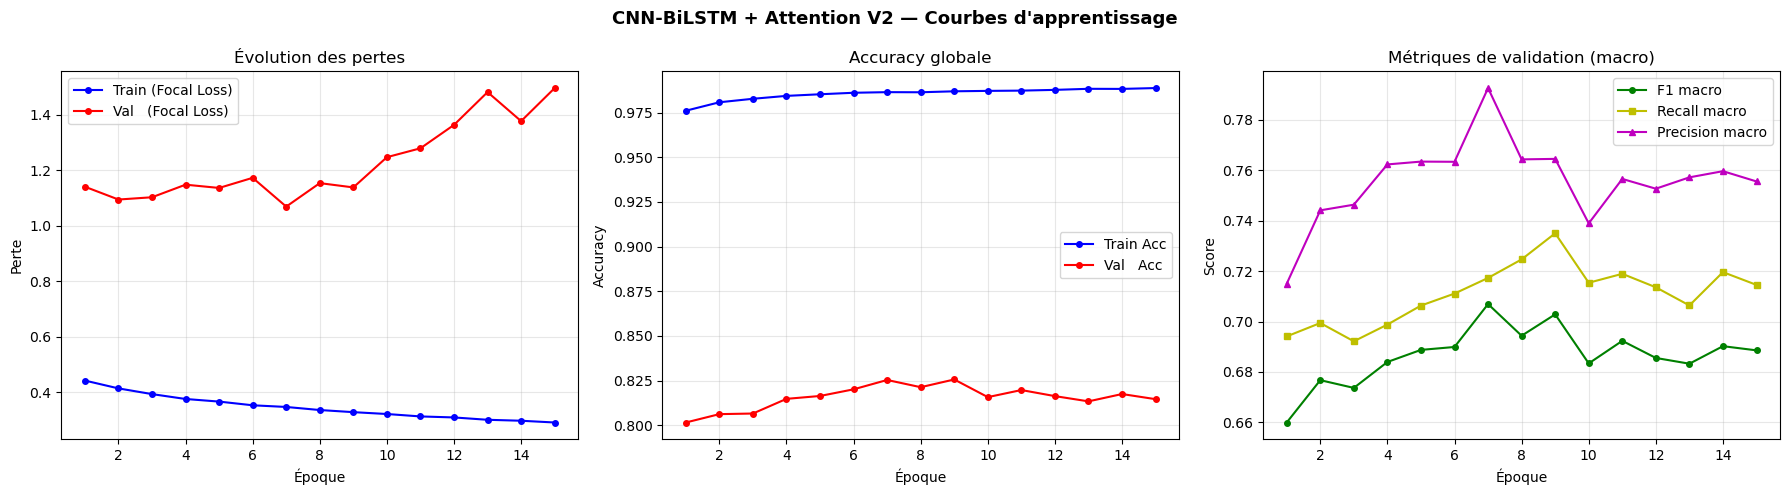

In [18]:
epochs_ran = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('CNN-BiLSTM + Attention V2 — Courbes d\'apprentissage', fontsize=13, fontweight='bold')

# Pertes
ax = axes[0]
ax.plot(epochs_ran, history['train_loss'], 'b-o', ms=4, label='Train (Focal Loss)')
ax.plot(epochs_ran, history['val_loss'],   'r-o', ms=4, label='Val   (Focal Loss)')
ax.set_xlabel('Époque'); ax.set_ylabel('Perte')
ax.set_title('Évolution des pertes'); ax.legend(); ax.grid(alpha=0.3)

# Accuracy
ax = axes[1]
ax.plot(epochs_ran, history['train_acc'], 'b-o', ms=4, label='Train Acc')
ax.plot(epochs_ran, history['val_acc'],   'r-o', ms=4, label='Val   Acc')
ax.set_xlabel('Époque'); ax.set_ylabel('Accuracy')
ax.set_title('Accuracy globale'); ax.legend(); ax.grid(alpha=0.3)

# F1 / Precision / Recall
ax = axes[2]
ax.plot(epochs_ran, history['val_f1'],        'g-o', ms=4, label='F1 macro')
ax.plot(epochs_ran, history['val_recall'],    'y-s', ms=4, label='Recall macro')
ax.plot(epochs_ran, history['val_precision'], 'm-^', ms=4, label='Precision macro')
ax.set_xlabel('Époque'); ax.set_ylabel('Score')
ax.set_title('Métriques de validation (macro)'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'courbes_v2.png'), dpi=150)
plt.show()

**Interprétation :**

Nous avons lancé l'entraînement du modèle sur 30 époques. Mais avec la configuration que nous avons défini, le early stopping a detecté un surapprentissage a stoppé l'entraînement avant la dernière époque puisqu'il n'y a pas d'amélioration du modèle. 

En effet, nous nous basons sur le score de F1 pour évaluer le modèle lors de la validation afin de pouvoir statuer sur les performances de celui-ci. L'utilisation de ce score au lieu de la fonction de perte permet d'évaluer les capacités globales du modèle dans la prédiction des classes individuellement. Avec cela, on peut remarquer sur la courbe des score de F1 que le meilleur modèle obtenu est celui enregistré à la 7e époque. Du côté de la loss, on peut voir que la plus faibe loss sur les données de validation a été obtenu au niveau de la 7e époque.

Après la 7e époque, bien que la train loss continue de diminuer légèrement, celle de la validation augmente, signe d'un manque de généralisation.

Nous enregistrons alors le modèle obtenu à la 7e époque car c'est la meilleur.

* **ÉVALUATION FINALE SUR LE JEU DE TEST**
  
   **Rapport de classification**

In [22]:
print('🔍 Évaluation finale sur le jeu de test...')


ckpt = torch.load('modèle/models/local/best_model_local.pt', map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

test_loss = t_ok = t_total = 0
all_preds = []; all_labels = []; all_probs = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Test'):
        tok   = batch['token_ids'].to(device)
        typ   = batch['type_ids'].to(device)
        elbl  = batch['labels'].to(device)
        llbl  = batch['line_numbers'].to(device)
        amask = batch['attention_mask'].to(device)

        e_logits, l_logits = model(tok, typ, amask)
        probs = torch.softmax(e_logits, dim=-1)

        loss_e = criterion_error(e_logits.view(-1, e_logits.size(-1)), elbl.view(-1))
        loss_l = criterion_line(l_logits.view(-1, l_logits.size(-1)),  llbl.view(-1))
        test_loss += (loss_e + LINE_LOSS_WEIGHT * loss_l).item()

        preds = e_logits.argmax(-1)
        mask  = (elbl != -100) & (amask == 1)
        t_ok    += (preds[mask] == elbl[mask]).sum().item()
        t_total += mask.sum().item()

        for i in range(elbl.size(0)):
            k = mask[i]
            all_preds.extend(preds[i][k].cpu().tolist())
            all_labels.extend(elbl[i][k].cpu().tolist())
            all_probs.extend(probs[i][k].cpu().tolist())

avg_test_loss = test_loss / len(test_loader)
test_acc      = t_ok / t_total if t_total else 0

all_classes   = list(train_dataset.id2label.values())
class_indices = list(range(len(all_classes)))

print(f'\nTest Loss     : {avg_test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}')
print('\n📊 Classification Report :')
print(classification_report(
    all_labels, all_preds,
    labels=class_indices, target_names=all_classes,
    zero_division=0
))

🔍 Évaluation finale sur le jeu de test...


Test:   0%|                                                                                     | 0/78 [00:00<?, ?it/s]C:\Users\HP\anaconda3\envs\pytorch311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Test: 100%|████████████████████████████████████████████████████████████████████████████| 78/78 [01:17<00:00,  1.00it/s]



Test Loss     : 1.2923
Test Accuracy : 0.8221

📊 Classification Report :
                       precision    recall  f1-score   support

              CORRECT       0.83      0.97      0.89    368389
      EXTRA_SEMICOLON       0.97      1.00      0.98     35550
         KEYWORD_TYPO       0.00      0.00      0.00     40279
        MISSING_BRACE       0.58      0.62      0.60     15625
        MISSING_PAREN       0.73      0.65      0.69     66971
    MISSING_SEMICOLON       0.79      0.42      0.55     35429
WRONG_OPERATOR_ASSIGN       0.93      0.95      0.94     15731
    WRONG_OPERATOR_EQ       0.68      0.94      0.79      4524

             accuracy                           0.82    582498
            macro avg       0.69      0.69      0.68    582498
         weighted avg       0.76      0.82      0.79    582498



**Interprétation :**

Avec cet rapport de classification sur les données de test, on peut voir que la précision dans les classes d'erreurs sont bonnes à l'exception de la classe constituant le regroupement de plusieurs autre, i.e la classe **KEYWORD_TYPO**. Elle a également un recall et un f1-score nul.

En effet, nous avions décidé de régrouper les classes sous représentées dans une seule classe avec l'hypothèse que la mauvaise capacité du modèle à reconnaître ces erreurs est du à un manque d'échantillon conséquent et aussi à un problème profond de confusion de tokens. Maintenant que nous avons un support conséquent et que malgré tous les métriques dans cette classe sont nulles, nous recentrons maintenant notre hypothèse sur le fait qu'il y ait des confusions des tokens d'erreur de ces classes.

* **Matrice de confusion**

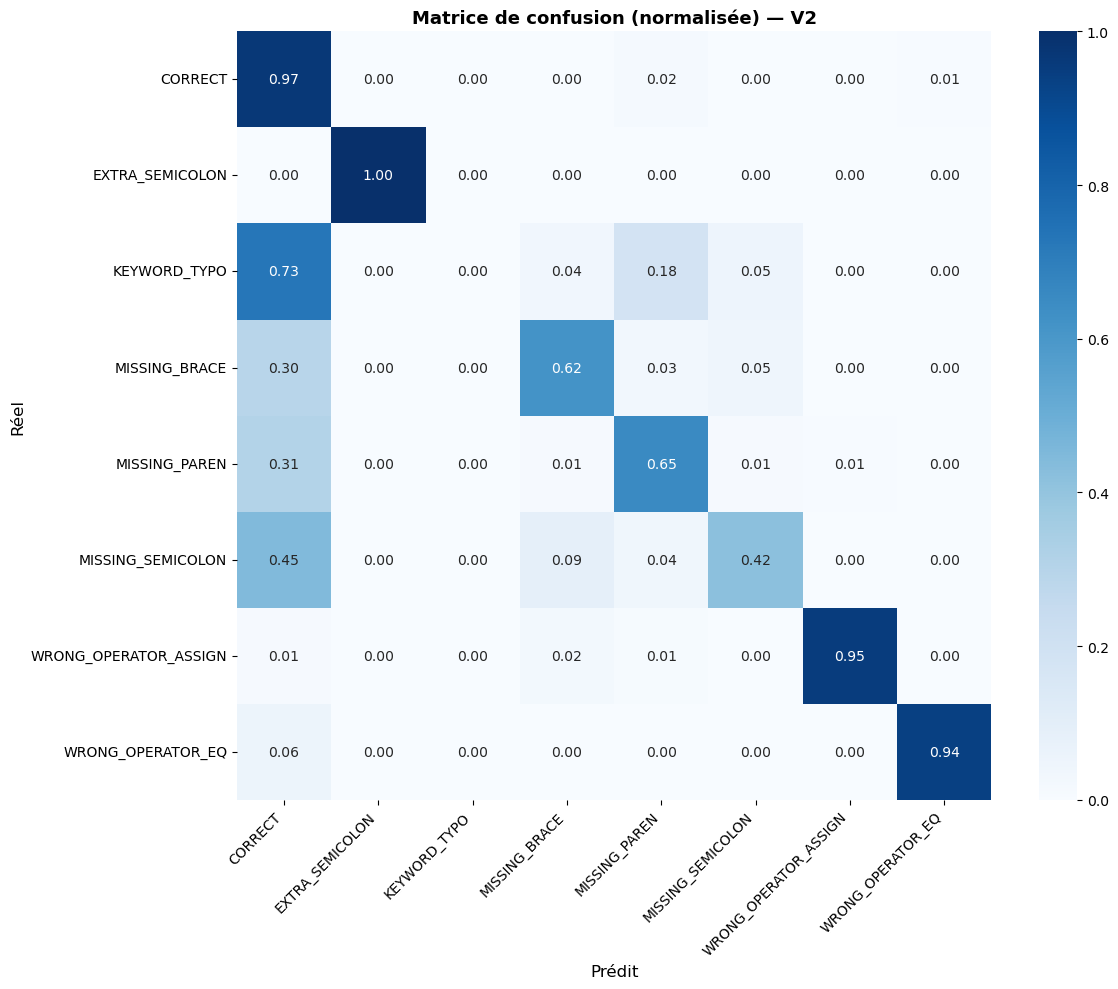

La matrice montre les confusions entre classes : les lignes sont les classes réelles.


In [24]:
import seaborn as sns
cm = confusion_matrix(all_labels, all_preds, labels=class_indices)

# Normalisation par ligne (recall par classe)
cm_norm = cm.astype(float)
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm  = np.where(row_sums > 0, cm_norm / row_sums, 0)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f',
    xticklabels=all_classes, yticklabels=all_classes,
    cmap='Blues', ax=ax, vmin=0, vmax=1
)
ax.set_xlabel('Prédit',  fontsize=12)
ax.set_ylabel('Réel',    fontsize=12)
ax.set_title('Matrice de confusion (normalisée) — V2', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix_v2.png'), dpi=150)
plt.show()
print('La matrice montre les confusions entre classes : les lignes sont les classes réelles.')

**Interprétation :**

La matrice de confusion montre les confusions entre les classes. Elle permet de statuer sur la capacité du modèle à reconnaître chaque classe d'erreur correctement.

On peut remarquer sur cette matrice de confusion que le modèle est en moyenne lucide dans ces classification sauf au niveau de 4 classes d'erreurs, principalement la classe **KEYWORD_TYPO** où il identifient comme correctes.

   **Courbes ROC**

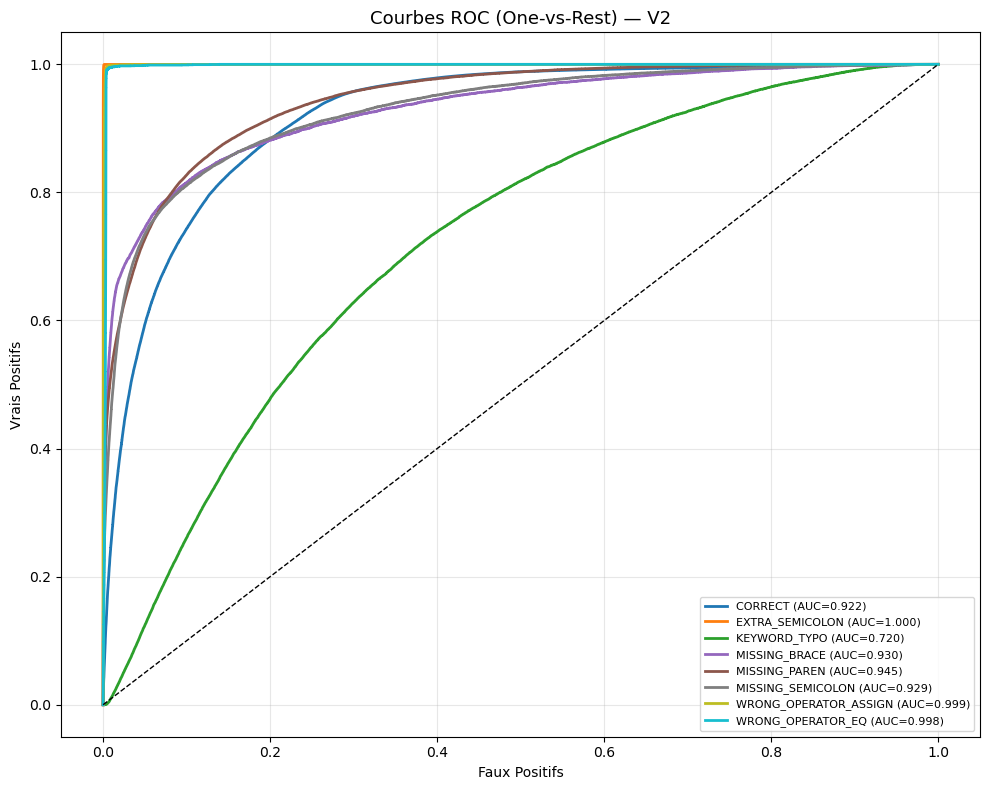


AUC par classe :
  EXTRA_SEMICOLON           : 1.000  ███████████████████
  WRONG_OPERATOR_ASSIGN     : 0.999  ███████████████████
  WRONG_OPERATOR_EQ         : 0.998  ███████████████████
  MISSING_PAREN             : 0.945  ██████████████████
  MISSING_BRACE             : 0.930  ██████████████████
  MISSING_SEMICOLON         : 0.929  ██████████████████
  CORRECT                   : 0.922  ██████████████████
  KEYWORD_TYPO              : 0.720  ██████████████


In [25]:
y_true_bin = label_binarize(all_labels, classes=class_indices)
y_score    = np.array(all_probs)

plt.figure(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(all_classes)))

aucs = {}
for i, cls in enumerate(all_classes):
    if np.sum(y_true_bin[:, i]) > 0:
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        aucs[cls] = roc_auc
        plt.plot(fpr, tpr, color=colors[i], lw=2,
                 label=f'{cls} (AUC={roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('Faux Positifs'); plt.ylabel('Vrais Positifs')
plt.title('Courbes ROC (One-vs-Rest) — V2', fontsize=13)
plt.legend(loc='lower right', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_v2.png'), dpi=150)
plt.show()

print('\nAUC par classe :')
for cls, a in sorted(aucs.items(), key=lambda x: -x[1]):
    bar = '█' * int(a * 20)
    print(f'  {cls:<25} : {a:.3f}  {bar}')

**Interprétation :**

L'AUC permet d'evaluer la capacité du modèle à pouvoir classer correctement les classes d'erreurs au detriment des faux positifs. 

On observe des scores d'AUC tous au dessus 50\% justifiant que le modèle a moins de faux positifs dans prédictions. Cela est en cohérence avec les résultats obtenu à travers le rapport de classification (plus haut). On observe comme au niveau du rapport de classification que le modèle est moins performant quand il s'agit de la classe d'erreur **KEYWORD_TYPO**.  

Dans la partie suivante, nous essayerons faire un fine tuning d'un modèle pré-entraîné sur nos données, ceci pour but d'essayer de combler le manque de performances observé au niveau du modèle CNN-BiLSTM.

<h1 style="text-align: center;">PARTIE III</h1>

<h4 style="text-align: center;">Fine tuning d'un modèle pré-entraîner (GraphCodeBert)</h4>

# Préparation du jeu de données

In [ ]:
def prepare_line_dataset(errored_dir, labels_dir):
    """
    Parcourt les fichiers JSON et les .txt correspondants pour créer une liste de (ligne, label).
    Retourne texts, labels, label2id, id2label.
    """
    texts = []
    labels = []
    label_set = set()

    # Parcourir les fichiers JSON
    for fname in os.listdir(labels_dir):
        if not fname.endswith('_labels.json'):
            continue
        base = fname.replace('_labels.json', '')
        txt_path = os.path.join(errored_dir, base + '_errored.txt')
        json_path = os.path.join(labels_dir, fname)

        if not os.path.exists(txt_path):
            print(f"Fichier .txt manquant : {txt_path}")
            continue

        # Lire le code erroné
        with open(txt_path, 'r', encoding='utf-8') as f:
            lines = f.readlines()

        # Lire les labels
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        token_labels = data['sequence']['labels']
        line_numbers = data['sequence']['line_numbers']

        # Grouper les labels par ligne
        line_to_labels = {}
        for lbl, ln in zip(token_labels, line_numbers):
            line_to_labels.setdefault(ln, []).append(lbl)

        # Pour chaque ligne, déterminer le label
        for ln, line_text in enumerate(lines, start=1):
            line_text = line_text.rstrip('\n')
            if ln in line_to_labels:
                lbls = line_to_labels[ln]
                # Si tous les tokens sont CORRECT, label = CORRECT
                if all(l == 'CORRECT' for l in lbls):
                    label = 'CORRECT'
                else:
                    # Prendre le premier label non-CORRECT (simplification)
                    non_correct = [l for l in lbls if l != 'CORRECT']
                    label = non_correct[0]  # ou on pourrait choisir le plus fréquent
            else:
                # Ligne sans token (vide ou commentaire seul) : on la considère correcte
                label = 'CORRECT'

            texts.append(line_text)
            label_set.add(label)
            labels.append(label)

    # Créer les mappings
    sorted_labels = sorted(label_set)
    if 'CORRECT' in sorted_labels:
        sorted_labels.remove('CORRECT')
        sorted_labels = ['CORRECT'] + sorted_labels
    label2id = {lbl: i for i, lbl in enumerate(sorted_labels)}
    id2label = {i: lbl for lbl, i in label2id.items()}

    # Convertir les labels en indices
    labels = [label2id[lbl] for lbl in labels]

    return texts, labels, label2id, id2label

# Exemple d'utilisation
if __name__ == "__main__":
    texts, labels, label2id, id2label = prepare_line_dataset(errored_dir, label_dir)
    print(f"Nombre d'échantillons : {len(texts)}")
    print(f"Classes : {label2id}")

## Séparation des données

In [ ]:
# Dans le même script ou un nouveau
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.3, random_state=42, stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train : {len(X_train)}, Val : {len(X_val)}, Test : {len(X_test)}")

## Tokenisation du code avec le tokeniseur de GrapheCodeBert

In [ ]:
from transformers import AutoTokenizer

model_name = "microsoft/graphcodebert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(texts):
    return tokenizer(texts, padding="max_length", truncation=True, max_length=128, return_tensors=None)

# On tokenisera pendant la création du dataset Hugging Face

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_dict({"text": X_train, "label": y_train})
val_dataset = Dataset.from_dict({"text": X_val, "label": y_val})
test_dataset = Dataset.from_dict({"text": X_test, "label": y_test})

# Appliquer la tokenization
train_dataset = train_dataset.map(lambda x: tokenizer(x["text"], padding="max_length", truncation=True, max_length=128), batched=True)
val_dataset = val_dataset.map(lambda x: tokenizer(x["text"], padding="max_length", truncation=True, max_length=128), batched=True)
test_dataset = test_dataset.map(lambda x: tokenizer(x["text"], padding="max_length", truncation=True, max_length=128), batched=True)

# Reformater pour PyTorch (les datasets Hugging Face sont compatibles)
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

## Configuration des hyperparamètres du modèle

In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

num_labels = len(label2id)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

# Pour transformers < 4.4.0
training_args = TrainingArguments(
    output_dir="résultats/results",
    eval_strategy="epoch",           # ancien nom
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="precision",
    logging_dir='résultats/logs',
    logging_steps=10,
    report_to="none"
)

# Entraînement

In [ ]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

## Évaluation

In [ ]:
test_results = trainer.evaluate(test_dataset)
print(test_results)

## Sauvegarde

In [ ]:
model.save_pretrained("./graphcodebert_finetuned")
tokenizer.save_pretrained("./graphcodebert_finetuned")

<h1 style="text-align: center;">PARTIE II</h1>

<h4 style="text-align: center;">Prédictions avec une interface graphique (Flask)</h4>

Interface réalisé avec le framework python Flask.

Lancement de l'interface depuis le terminal VSCode ou en ligne de commande :

\>se placer dans le dossier du projet

\> conda activate pytorch311

\> python app.py

# Conclusion

Ce projet nous a permis d'explorer en long et en large, le domaine complexe du traitement automatique de langues naturelles. Notre travail, centré sur le traitement de code au lieu de langues naturelles, a nécessité une compréhension plus fine de concepts importants tels que la tokenisation, l'embeddings et bien d'autres. Nous avons bien-sûr rencontré des difficultés au cour du projet. Ces difficultés partent de la mise en place du corpus de codes riche à l'obtention d'un modèle performant. Il reste par contre quelques faiblesses dans notre modèle car celui-ci a toujours du mal à prédire correctement certaines classes d'erreurs. Quant au modèle fine tuné, celui-ci est performant mais la contrainte principale est que son entraînement dur longtemps et nécessite beaucoup de moyens de calcul. Nous allons poursuivre l'entraînement des deux modèles et espérons présenté des modèle performants le jour de la demonstration.